# Notebook 03 — Analysis

**Purpose:** Full analysis pipeline for the 64-trial COPD digital health
evidence map: descriptive characterisation, PROGRESS-Plus equity reporting,
digital strategy landscape, three pre-specified inferential hypotheses,
and sensitivity analyses.

**Data Flow:**

| Direction | File | From / To |
| --------- | ---- | --------- |
| Input | `data/processed/arms.csv` | Notebook 00 |
| Input | `data/processed/trials.csv` | Notebook 00 |
| Input | `outputs/tables/pipeline/inter_run_ambiguous_flags.csv` | Notebook 01 |
| Output | `outputs/figures/` | Thesis Figures 1–9 |
| Output | `outputs/tables/` | Thesis Results tables |

**Prerequisite notebooks:** N00 (arms + trials), N01 (ambiguous flags).

> **Note:** This notebook merges the former `03_representativeness`,
> `04_inferential_hypotheses`, and `05_sensitivity_analyses` notebooks
> (archived in `notebooks/legacy/`).

**Index:**

| Section | What it does |
| :------- | :------------ |
| 0 | Setup — paths, imports, helper functions |
| 1 | Load processed data (arms, trials, ambiguous flags) |
| 2.1 | Publication year distribution (histogram + period buckets) |
| 2.2 | Geographic distribution (continent + country counts) |
| 2.3 | Sample size distribution (histogram, capped at n=400) |
| 2.4 | Healthcare setting (arm-level + combined corpus figure) |
| 2.5 | Diagnosis distribution (COPD only vs COPD + other) |
| 3.1 | Participant-weighted baseline means per trial |
| 3.2 | Participant-weighted pooling across trials |
| 3.3 | Baseline comparison table (trials vs reference cohorts) |
| 3.4 | Trial-level heterogeneity (beeswarm scatter + forest plots) |
| 4.1 | PROGRESS-Plus reporting per domain (trial-level) |
| 5 | modified PROGRESS-Plus composite score (0–9) |
| 6 | Digital strategy aggregation (arm → trial, any_true) |
| 7 | Digital inclusiveness score (0–5) + 4-way co-occurrence |
| 8 | H1 — Equity reporting over time (OLS + diagnostics) |
| 9 | H2 — Representativeness over time (age + FEV1, OLS + diagnostics) |
| 10 | H3 — Equity vs digital inclusiveness (partial regression + diagnostics) |
| 11 | Compile inferential results table |
| 12 | Sensitivity 1 — Arm-level vs trial-level baseline |
| 13 | Sensitivity 2 — Weighted vs unweighted pooling |
| 14 | Sensitivity 3 — Influential observations (Cook's D refit) |
| 15 | Results-ready statements (primary + sensitivity) |
| 16 | Summary export (key counts + figures/tables list) |
| Appendix | Supplementary figures (patient-level spread, cohort comparison) |

> **Shared code:** Uses `src/data_loading.py` (load arms, references),
> `src/aggregation.py` (arm-to-trial aggregation, PROGRESS-Plus classification,
> composite score computation), `src/statistics.py` (SMD, VIF, Cook's D,
> correlation), `src/plotting.py` (all figures, save_figure), and
> `src/geography.py` (continent mapping). Build scripts in `scripts/` handle
> combined figures.

**Notebook-specific notes:**

- **Score construction:** The modified PROGRESS-Plus composite score (0–9) is
  computed once in §5 via `compute_progress_plus_composite_scores()` and reused
  across §8 (H1), §10 (H3), §11 (results table), and §14–15 (sensitivity +
  results-ready statements). Changing the score logic requires changing only
  `src/aggregation.py` and re-running this notebook.
- **Figure order in S8–S10:** Each hypothesis section is structured as: primary
  plot → numeric results → diagnostics plot. This allows comparing the main
  figure with the regression table before seeing diagnostics.


## Contents

- [0: Setup](#Section-0-setup)
- [1: Load processed data](#Section-1-load-processed-data)
- [2.1: Publication year distribution](#Section-2.1-publication-year-distribution)
- [2.2: Geographic distribution](#Section-2.2-geographic-distribution)
- [2.3: Sample size distribution](#Section-2.3-sample-size-distribution)
- [2.4: Healthcare setting](#Section-2.4-healthcare-setting)
- [2.5: Diagnosis distribution](#Section-2.5-diagnosis-distribution)
- [3: Baseline pooling and heterogeneity](#Section-3-baseline-pooling-and-heterogeneity)
  - [3.1: Participant-weighted baselines](#Section-3.1-participant-weighted-baselines)
  - [3.2: Participant-weighted pooling](#Section-3.2-participant-weighted-pooling)
  - [3.3: Comparison table](#Section-3.3-comparison-table)
  - [3.4: Trial-level heterogeneity](#Section-3.4-trial-level-heterogeneity)
- [4: PROGRESS-Plus reporting](#Section-4-progress-plus-reporting)
  - [4.1: Reporting (trial-level)](#Section-4.1-progress-plus-reporting-trial-level)
- [5: Modified PROGRESS-Plus composite score](#Section-5-modified-progress-plus-composite-score)
- [6: Digital strategy aggregation](#Section-6-digital-strategy-aggregation)
- [7: Digital inclusiveness score](#Section-7-digital-inclusiveness-score)
- [8: H1 — Equity reporting over time](#Section-8-hypothesis-1-equity-reporting-over-time)
- [9: H2 — Representativeness over time](#Section-9-hypothesis-2-representativeness-over-time)
- [10: H3 — Equity vs digital inclusiveness](#Section-10-hypothesis-3-equity-vs-digital-inclusiveness)
- [11: Compile results table](#Section-11-compile-results-table)
- [12: Sensitivity 1 — Arm-level vs trial-level](#Section-12-sensitivity-1-arm-level-vs-trial-level)
- [13: Sensitivity 2 — Weighted vs unweighted pooling](#Section-13-sensitivity-2-weighted-vs-unweighted-pooling)
- [14: Sensitivity 3 — Influential observations](#Section-14-sensitivity-3-influential-observations)
- [15: Results-ready statements](#Section-15-results-ready-statements)
- [16: Summary export](#Section-16-summary-export)

## Section 0: Setup

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

ROOT = Path().resolve().parent if Path().resolve().name == "notebooks"          else Path().resolve()
sys.path.insert(0, str(ROOT))

# ── External libraries ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats
from matplotlib.ticker import MaxNLocator

# ── Project modules (src/) ───────────────────────────────────────────────────
from src.analysis.data_loading import load_arms, load_references
from src.analysis.data_loading import parse_structured_array, get_schema_hash

from src.analysis.aggregation import arm_weighted_mean_per_trial
from src.analysis.aggregation import weighted_mean_across_trials, simple_mean_across_trials
from src.analysis.aggregation import aggregate_boolean_at_trial
from src.analysis.aggregation import classify_equity_reporting
from src.analysis.aggregation import pooled_within_trial_sd
from src.analysis.aggregation import compute_progress_plus_composite_scores

from src.analysis.statistics import compute_smd_table
from src.analysis.statistics import pearson_correlation, spearman_correlation, vif_from_model, cooks_distance

from src.analysis.plotting import PALETTE, BLUE, ORANGE, GREEN, RED, GRAY
from src.analysis.plotting import save_figure
from src.analysis.plotting import histogram_with_stats
from src.analysis.plotting import scatter_with_regression
from src.analysis.plotting import trial_scatter_means
from src.analysis.plotting import forest_plot_means, bar_with_ci
from src.analysis.plotting import forest_plot_smd
from src.analysis.plotting import stacked_bar_crosstab, stacked_bar_crosstab_dual
from src.analysis.plotting import regression_diagnostics_plot, axis_break_x

from scripts.build_fig_corpus_combined_a import build_fig_continent_by_period, build_fig_setting_by_period
from scripts.build_fig4_combined import build_fig_progressplus_score, build_fig_progressplus_reporting
from scripts.build_fig6_combined import build_fig6_combined

from src.analysis.geography import get_continent

# ── Configuration ────────────────────────────────────────────────────────────
plt.ion()

# ── Paths ────────────────────────────────────────────────────────────────────
ARMS_PATH = ROOT / "data" / "processed" / "arms.csv"
TRIALS_PATH = ROOT / "data" / "processed" / "trials.csv"
AMBIGUOUS_FLAGS_PATH = ROOT / "outputs" / "tables" / "pipeline" / "inter_run_ambiguous_flags.csv"
OUTPUT_TABLES = ROOT / "outputs" / "tables"
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)

## Section 1: Load processed data

In [2]:
# Load processed data from N00 and N01. Separate treatment arms for digital
# strategy analysis. Load ambiguous NA flags from N01 inter-run consistency.
arms = load_arms(ARMS_PATH)
int_arms = arms[arms["arm"].isin(["treat1", "treat2"])]
trials = pd.read_csv(TRIALS_PATH)
refs = load_references()

print(f"Arms: {arms.shape}, Trials: {len(trials)}")
print(f"N trials = {trials['cov_nr'].nunique()}, N arms = {len(arms)}")

# Load ambiguous NA flags from notebook 01
ambiguous_na = None
if AMBIGUOUS_FLAGS_PATH.exists():
    one_na_cases_df = pd.read_csv(AMBIGUOUS_FLAGS_PATH)
    progress_plus_fields = ['ses',
    'ses_income', 'ses_living_situation', 'ses_relationship_status',
                 'ses_job_status', 'ses_living_location', 'educational_level',
                 'ethnicity', 'health_literacy', 'digital_literacy']
    progress_plus_one_na = one_na_cases_df[one_na_cases_df['field_name'].isin(progress_plus_fields)]
    # Build dict: field_name -> set of cov_nr with one-NA
    ambiguous_na = {}
    for field in progress_plus_fields:
        subset = progress_plus_one_na[progress_plus_one_na['field_name'] == field]
        if len(subset) > 0:
            ambiguous_na[field] = set(subset['cov_nr'].unique())
    print(f"Ambiguous-NA fields loaded: {list(ambiguous_na.keys())}")
else:
    print("No inter_run_ambiguous_flags.csv found — skipping ambiguous classification")


Arms: (134, 71), Trials: 64
N trials = 64, N arms = 134
Ambiguous-NA fields loaded: ['ses_income', 'ses_living_situation', 'ses_relationship_status']


## Section 2.1: Publication year distribution

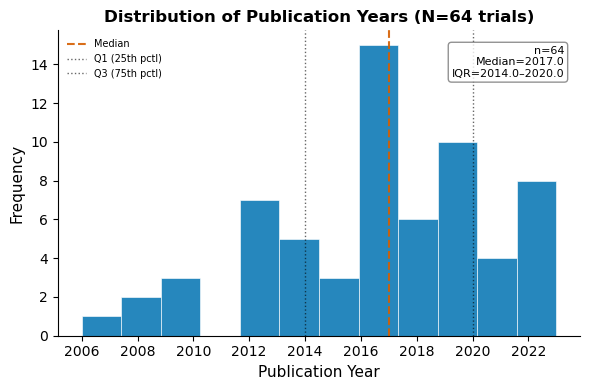

→ Thesis Figure 1 (publication year distribution)
Year range: 2006-2023, median: 2017, mean: 2016.75, SD: 4.05


In [3]:
# Publication year distribution. Three periods reflect digital-health phases:
# 2006–2014 (proof-of-concept), 2015–2019 (smartphone consolidation),
# 2020–2023 (pandemic-accelerated).

# fig1a: year histogram
years = trials['publication_year'].dropna()
fig = histogram_with_stats(
    years.values,
    xlabel="Publication Year", title="Distribution of Publication Years (N=64 trials)",
    bins=12, color=BLUE, integer_x=True,
)
save_figure(fig, "fig1b_trials_by_year")
print("→ Thesis Figure 1 (publication year distribution)")
print(f"Year range: {years.min():.0f}-{years.max():.0f}, median: {years.median():.0f}, mean: {years.mean():.2f}, SD: {years.std():.2f}")

# Continent mapping + two bucket systems for stacked bars
trials['continent'] = trials['country'].apply(get_continent)
trials['bucket_eq'] = pd.cut(trials['publication_year'],
                              bins=[2005, 2011, 2017, 2024],
                              labels=['2006-2011', '2012-2017', '2018-2023'])
trials['bucket_ph'] = pd.cut(trials['publication_year'],
                              bins=[2005, 2014, 2019, 2024],
                              labels=['2006-2014', '2015-2019', '2020-2023'])

# Combined figure (continent + setting, dual-axis)
# Generate combined corpus figure (continent + healthcare setting)

## Section 2.2: Geographic distribution

Unique countries: 21

Continent distribution:
continent
Europe             37
North America      13
Asia                7
Oceania             6
Multi-continent     1


country
Denmark                                                   12
USA                                                       11
UK                                                         8
Australia                                                  5
Netherlands                                                4
Spain                                                      3
Taiwan                                                     3
China                                                      3
Belgium                                                    2
Canada                                                     2
Italy                                                      1
New Zealand                                                1
Belgium and Spain                                          1
Europe (Belgium, Greece, UK, Sw

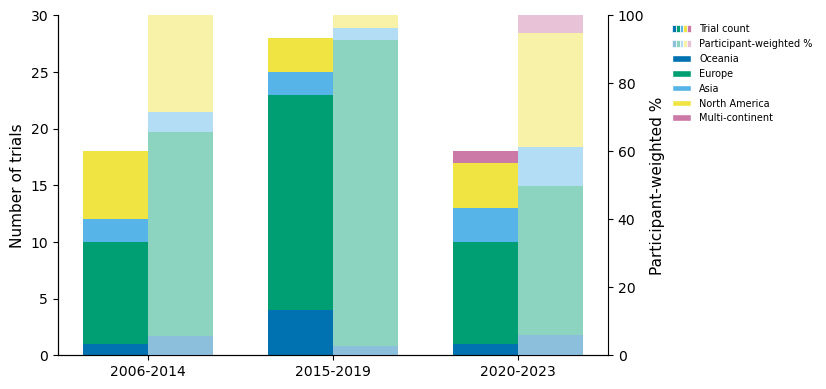

→ Thesis Figure 3 (trials by continent and period)


In [4]:
# Country and continent distribution. Multi-country strings counted as-is.
# get_continent() resolves them to continent labels.
country_counts = trials['country'].value_counts()
cont_counts = trials['continent'].value_counts()

# Print continent distribution first

print(f"Unique countries: {len(country_counts)}")
print("\nContinent distribution:")
print(cont_counts.to_string())

# Print country distribution second
print("\n")
print(country_counts.to_string())

# Save table
geo_df = pd.DataFrame({
    'region': country_counts.index,
    'n_trials': country_counts.values,
})
geo_df = geo_df.sort_values('n_trials', ascending=False)
geo_df.to_csv(OUTPUT_TABLES / 'table1b_geography.csv', index=False)
print("\nSaved: table1_geography.csv")


# Continent-by-period stacked bars (Figure 3)
fig_cont = build_fig_continent_by_period(trials)
save_figure(fig_cont, "fig3_continent_by_period")
print("→ Thesis Figure 3 (trials by continent and period)")

## Section 2.3: Sample size distribution

Capped trials (n > 400, out of scope): [1400, 3116, 4727, 5563]


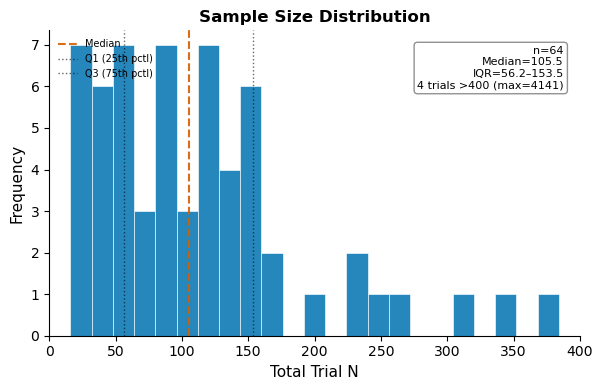

→ Supplementary (sample size distribution)
Sample size: median=106, IQR=56-154
Range: 17-4141
Pilot-scale trials (n<30): 5 / 64
  cov_nr: [157, 4108, 4123, 5339, 5777]


In [5]:
# Trial sample size distribution. Right tail trimmed at n=400 for readability.
# Pilot-scale (<30) trials flagged separately — typically feasibility studies.
trial_n = trials['total_n'].dropna()
n_cutoff = 400
n_outliers = (trial_n > n_cutoff).sum()
max_n = int(trial_n.max())
extra = f"{n_outliers} trials >{n_cutoff} (max={max_n})"
if n_outliers > 0:
    capped_ids = trials.loc[trial_n > n_cutoff, 'cov_nr'].tolist()
    print(f"Capped trials (n > {n_cutoff}, out of scope): {sorted(capped_ids)}")
fig = histogram_with_stats(
    trial_n.values, xlabel="Total Trial N", title="Sample Size Distribution",
    bins=25, color=BLUE, extra_text=extra, hist_range=(0, n_cutoff),
)
ax = fig.axes[0]
ax.set_xlim(0, n_cutoff)
save_figure(fig, "fig1e_sample_size_distribution")
print("→ Supplementary (sample size distribution)")

print(f"Sample size: median={trial_n.median():.0f}, IQR={trial_n.quantile(0.25):.0f}-{trial_n.quantile(0.75):.0f}")
print(f"Range: {trial_n.min():.0f}-{trial_n.max():.0f}")
pilot = trials[trials['total_n'] < 30]
print(f"Pilot-scale trials (n<30): {len(pilot)} / {len(trials)}")
if len(pilot) > 0:
    print(f"  cov_nr: {pilot['cov_nr'].tolist()}")


## Section 2.4: Healthcare setting

     setting  n_arms        pct
0  Secondary     105  78.358209
1  Community      15  11.194030
2    Primary      14  10.447761
Saved: table2_setting_arm.csv


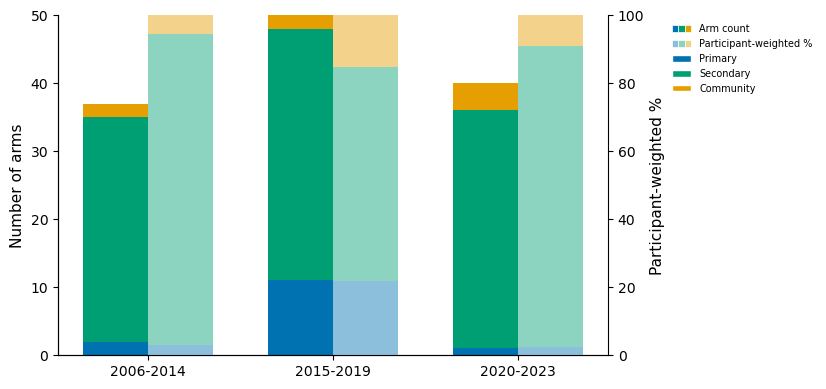

→ Thesis Figure 4 (trial-arms by setting and period)


In [6]:
# Healthcare setting: arm-level counts.

# Arm-level setting table and stacked bars (merge buckets without modifying arms)
arms_plot = arms.merge(trials[['cov_nr', 'bucket_eq', 'bucket_ph']], on='cov_nr', how='left')
arms_plot = arms_plot.dropna(subset=['bucket_eq', 'bucket_ph', 'healthcare_setting_label'])
setting_counts = arms_plot['healthcare_setting_label'].value_counts()
setting_df = pd.DataFrame({'setting': setting_counts.index, 'n_arms': setting_counts.values})
setting_df['pct'] = setting_df['n_arms'] / len(arms_plot) * 100
setting_df.to_csv(OUTPUT_TABLES / 'table2_setting_arm.csv', index=False)
print(setting_df.to_string())
print("Saved: table2_setting_arm.csv")

# Dual-panel stacked bars by period (Figure 4)
fig_set = build_fig_setting_by_period(arms_plot)
save_figure(fig_set, "fig4_setting_by_period")
print("→ Thesis Figure 4 (trial-arms by setting and period)")


## Section 2.5: Diagnosis distribution
For the purpose of the COPD analysis, the decision was made to split
trial arms into `COPD only` (arm enrolled exclusively COPD patients)
and `COPD + other` (arm included a mix of COPD plus other respiratory
or cardiovascular conditions). This classification is based on the
structured-array diagnosis field and determines whether a trial's
findings are COPD-specific or mixed-population.


In [7]:
# Classify each arm's diagnosis as 'COPD only' or 'COPD + other'
# by checking structured-array keys in the diagnosis field.
def classify_diagnosis(value):
    parsed = parse_structured_array(value)
    if parsed is None:
        return 'Unknown'
    keys = {k for k, _ in parsed if k.strip()}
    if any('COPD' not in k for k in keys):
        return 'COPD + other'
    return 'COPD only'

arms['diagnosis_class'] = arms['diagnosis'].apply(classify_diagnosis)
print("Diagnosis classification:")
print(arms['diagnosis_class'].value_counts().to_string())


Diagnosis classification:
diagnosis_class
COPD only       130
COPD + other      4


## Section 3: Baseline pooling and heterogeneity

## Section 3.1: Participant-weighted baselines

In [8]:
# Compute trial-level n-weighted means for 4 core baseline variables.
# Each arm weighted by its sample size; large arms contribute more.
baseline_cols = ['age_mean', 'gender_pct_female', 'fev1_pct_mean', 'bmi_mean']
trial_baselines = trials[['cov_nr', 'total_n']].copy()

for col in baseline_cols:
    wm = arm_weighted_mean_per_trial(arms, col, 'n', 'cov_nr')
    trial_baselines[col] = trial_baselines['cov_nr'].map(wm)

for col in baseline_cols:
    n_valid = trial_baselines[col].notna().sum()
    print(f"  {col}: {n_valid}/{len(trials)} trials with data")


  age_mean: 59/64 trials with data
  gender_pct_female: 61/64 trials with data
  fev1_pct_mean: 49/64 trials with data
  bmi_mean: 32/64 trials with data


## Section 3.2: Participant-weighted pooling

In [9]:
# Participant-weighted pooling across trials. Each trial weighted by total N.
# Unweighted mean shown as sensitivity check. Reference cohorts: ECLIPSE
# (international), Adelphi DSP (European), Nijmegen CSI (Dutch).
pooled = {}
for col in baseline_cols:
    p = weighted_mean_across_trials(trial_baselines, col, 'total_n')
    p_unw = simple_mean_across_trials(trial_baselines, col)
    pooled[col] = {**p, 'unweighted_mean': p_unw['mean']}
    print(f"\n{col}:")
    print(f"  Participant-weighted: {p['weighted_mean']:.1f} [{p['ci_lower']:.1f}, {p['ci_upper']:.1f}]  (each trial weighted by total N)")
    print(f"  Trial-weighted: {p_unw['mean']:.1f} [{p_unw['ci_lower']:.1f}, {p_unw['ci_upper']:.1f}]  (each trial = 1 vote)")
    print(f"  N trials: {p['n_trials']}")

# Build comparison table
table_rows = []
ref_labels = {
    'eclipse': ('ECLIPSE', 2164),
    'adelphi': ('Adelphi DSP', 2876),
    'nijmegen': ('Nijmegen outpatient', 168),
    'nijmegen_rehab': ('Nijmegen rehab', 131),
}
baseline_var_names = {
    'age_mean': ('Mean age (years)', 'age_years'),
    'gender_pct_female': ('% Female', 'female_pct'),
    'fev1_pct_mean': ('FEV1% predicted', 'fev1_pct_predicted'),
    'bmi_mean': ('BMI (kg/m2)', 'bmi_kg_m2'),
}

for var, (label, ref_key) in baseline_var_names.items():
    p = pooled[var]
    row = {
        'variable': label,
        'trial_estimate': f"{p['weighted_mean']:.1f}",
        'trial_95CI': f"[{p['ci_lower']:.1f}, {p['ci_upper']:.1f}]",
        'trial_SE': f"{p['se_weighted_mean']:.2f}" if p['se_weighted_mean'] is not None else '—',
        'n_trials': p['n_trials'],
    }
    for ref_name, (ref_label, ref_n) in ref_labels.items():
        ref = refs.get(ref_name, {}).get(ref_key, {})
        if ref:
            sd_str = f" ({ref['sd']:.1f})" if ref.get('sd') is not None else ''
            row[f'{ref_label}_mean_sd'] = f"{ref['mean']:.1f}{sd_str}"
            row[f'{ref_label}_n'] = ref['n']
        else:
            row[f'{ref_label}_mean_sd'] = '—'
            row[f'{ref_label}_n'] = '—'

    table_rows.append(row)

stable_df = pd.DataFrame(table_rows)
stable_df.to_csv(OUTPUT_TABLES / 'table3a_baseline_comparison.csv', index=False)
print("\nSaved: table3_baseline_comparison.csv")
pd.set_option('display.width', 300)
pd.set_option('display.max_columns', 15)
print(stable_df.to_string())



age_mean:
  Participant-weighted: 69.8 [68.4, 71.2]  (each trial weighted by total N)
  Trial-weighted: 68.4 [67.6, 69.2]  (each trial = 1 vote)
  N trials: 59

gender_pct_female:
  Participant-weighted: 46.0 [41.0, 51.0]  (each trial weighted by total N)
  Trial-weighted: 40.4 [36.0, 44.8]  (each trial = 1 vote)
  N trials: 61

fev1_pct_mean:
  Participant-weighted: 47.5 [45.4, 49.6]  (each trial weighted by total N)
  Trial-weighted: 48.2 [45.6, 50.8]  (each trial = 1 vote)
  N trials: 49

bmi_mean:
  Participant-weighted: 26.5 [25.6, 27.3]  (each trial weighted by total N)
  Trial-weighted: 26.5 [25.7, 27.3]  (each trial = 1 vote)
  N trials: 32

Saved: table3_baseline_comparison.csv
           variable trial_estimate    trial_95CI trial_SE  n_trials ECLIPSE_mean_sd  ECLIPSE_n Adelphi DSP_mean_sd  Adelphi DSP_n Nijmegen outpatient_mean_sd  Nijmegen outpatient_n Nijmegen rehab_mean_sd  Nijmegen rehab_n
0  Mean age (years)           69.8  [68.4, 71.2]     0.72        59      63.4 (7.

## Section 3.3: Comparison table

Trial pool estimates against 4 reference cohorts. Table saved to `table3a_baseline_comparison.csv`.

In [10]:
# Compute within-trial pooled SDs via degrees-of-freedom weighting.
# Patient-level spread, comparable to reference cohort SDs.
sd_fields = {
    'age_mean': ('age_sd', 'age_years'),
    'fev1_pct_mean': ('fev1_pct_sd', 'fev1_pct_predicted'),
    'bmi_mean': ('bmi_sd', 'bmi_kg_m2'),
}
sd_comparison = {}
for var, (sd_col, ref_key) in sd_fields.items():
    result = pooled_within_trial_sd(arms, sd_col, 'n')
    ref_sds = {}
    for ref_name in ref_labels:
        ref = refs.get(ref_name, {}).get(ref_key, {})
        ref_sds[ref_name] = ref.get('sd')
    sd_comparison[var] = {**result, 'ref_sds': ref_sds}

# --- Shared plot setup ---
ref_order = ['eclipse', 'adelphi', 'nijmegen', 'nijmegen_rehab']
ref_labels_short = ['ECLIPSE (mean)', 'Adelphi DSP (mean)', 'Nijmegen CSI, OP (mean)', 'Nijmegen CSI, PR (mean)']
ref_colors = [ORANGE, GREEN, '#CC79A7', '#D55E00']


## Section 3.4: Trial-level heterogeneity

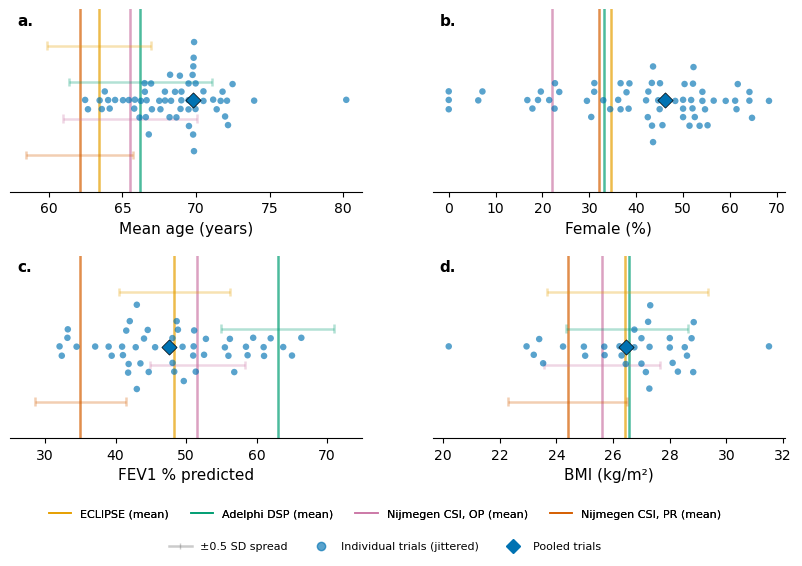

→ Thesis Figure 5a (trial-level heterogeneity, base)


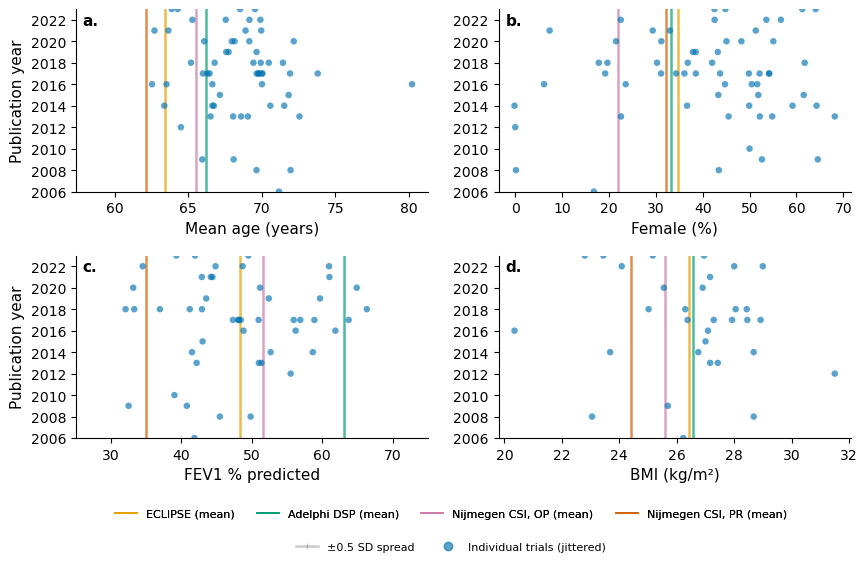

→ Thesis Figure 5b (trial-level heterogeneity, year y-axis)


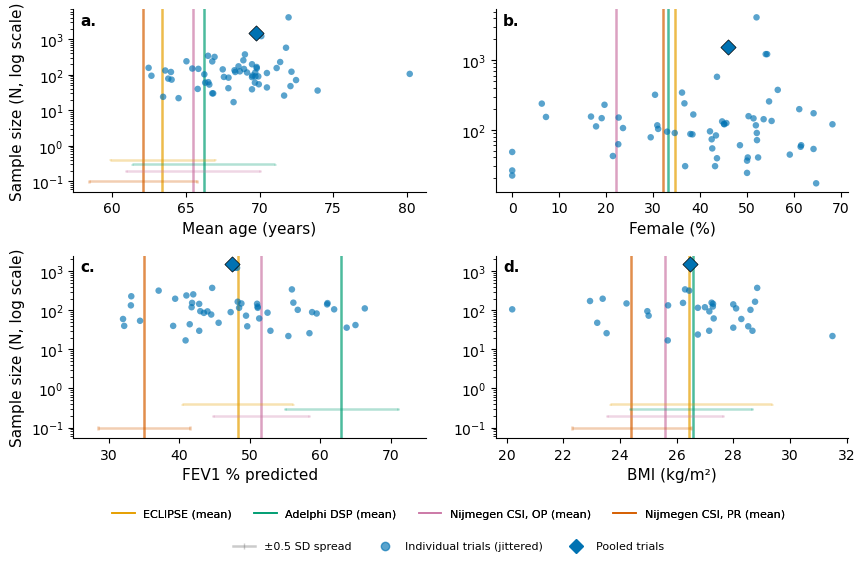

→ Thesis Figure 5c (trial-level heterogeneity, sample size y-axis)


In [11]:
# Shared x-axis labels for all three scatter versions
scatter_xlabels = {
    'age_mean': "Mean age (years)",
    'gender_pct_female': "Female (%)",
    'fev1_pct_mean': "FEV1 % predicted",
    'bmi_mean': "BMI (kg/m\u00b2)",
}

# Version 1 — Base (beeswarm, no substantive y-axis)
fig = trial_scatter_means(
    trial_baselines, pooled, refs, baseline_var_names,
    ref_order, ref_labels_short, ref_colors,
    x_limits={'fev1_pct_mean': (25, 75)},
    ref_x_shifts={'eclipse': -0.07, 'adelphi': 0.07},
    show_title=False,
    y_mode="beeswarm",
    x_labels=scatter_xlabels,
)
save_figure(fig, "fig5_trial_scatter_base", dpi=300)
print("\u2192 Thesis Figure 5a (trial-level heterogeneity, base)")

# Version 2 — Publication year y-axis
trial_baselines_year = trial_baselines.merge(
    trials[['cov_nr', 'publication_year']], on='cov_nr', how='left'
)
fig_year = trial_scatter_means(
    trial_baselines_year, pooled, refs, baseline_var_names,
    ref_order, ref_labels_short, ref_colors,
    x_limits={'fev1_pct_mean': (25, 75)},
    ref_x_shifts={'eclipse': -0.07, 'adelphi': 0.07},
    show_title=False,
    y_mode="year",
    x_labels=scatter_xlabels,
)
save_figure(fig_year, "fig5_trial_scatter_year", dpi=300)
print("\u2192 Thesis Figure 5b (trial-level heterogeneity, year y-axis)")

# Version 3 — Sample size y-axis (log scale)
# Participant-weighted pooled N = weighted mean of total_n (self-weighted)
pooled_n_val = float(
    np.average(trial_baselines['total_n'].dropna(),
               weights=trial_baselines.loc[trial_baselines['total_n'].notna(), 'total_n'])
)
fig_n = trial_scatter_means(
    trial_baselines, pooled, refs, baseline_var_names,
    ref_order, ref_labels_short, ref_colors,
    x_limits={'fev1_pct_mean': (25, 75)},
    ref_x_shifts={'eclipse': -0.07, 'adelphi': 0.07},
    show_title=False,
    y_mode="n",
    x_labels=scatter_xlabels,
    pooled_n=pooled_n_val,
)
save_figure(fig_n, "fig5_trial_scatter_n", dpi=300)
print("\u2192 Thesis Figure 5c (trial-level heterogeneity, sample size y-axis)")

**Figure 3 — Trial-level heterogeneity:**

Each dot represents the mean baseline value from a single trial with beeswarm positioning to avoid overlap. The pooled estimate (diamond) and reference cohort means (solid lines) show how individual trial populations distribute relative to selected COPD cohorts. Horizontal I-bars show ±0.5 *SD* around each reference mean.

Reference cohorts: ECLIPSE (Evaluation of COPD Longitudinally to Identify Predictive Surrogate Endpoints) (mean), Adelphi DSP (Adelphi Disease-Specific Programme) (mean), Nijmegen CSI (Clinical Screening Instrument) outpatient (mean), and Nijmegen CSI rehabilitation (mean).

## Section 4: PROGRESS-Plus reporting

## Section 4.1: PROGRESS-Plus reporting (trial-level)

In [12]:
# PROGRESS-Plus reporting per domain. ambiguous_na from N01 flags unresolved
# cases. Social capital (combined) = reported if EITHER sub-field has data.
PROGRESS_PLUS_FIELDS = {
    'Place of residence': 'ses_living_location',
    'Ethnicity': 'ethnicity',
    'Occupation': 'ses_job_status',
    'Sex/gender': 'gender_pct_female',
    'Education': 'educational_level',
    'Income': 'ses_income',
    'Social capital (relationship)': 'ses_relationship_status',
    'Social capital (living)': 'ses_living_situation',
    'Health literacy': 'health_literacy',
    'Digital literacy': 'digital_literacy',
}

reporting_data = []
for label, field in PROGRESS_PLUS_FIELDS.items():
    amb_set = ambiguous_na.get(field, set()) if ambiguous_na else set()
    reporting = classify_equity_reporting(arms, field, ambiguous_cov_nrs=amb_set)
    n_reported = (reporting == 'reported').sum()
    n_not = (reporting == 'not_reported').sum()
    n_amb = (reporting == 'ambiguous').sum()

    prop = n_reported / (n_reported + n_not + n_amb)
    reporting_data.append({
        'domain': label, 'field': field,
        'reported': n_reported, 'not_reported': n_not, 'ambiguous': n_amb,
        'proportion': prop,
    })

# Social capital (combined): reported if EITHER relationship OR living is reported
rel_reporting = classify_equity_reporting(arms, 'ses_relationship_status',
    ambiguous_cov_nrs=ambiguous_na.get('ses_relationship_status', set()) if ambiguous_na else None)
liv_reporting = classify_equity_reporting(arms, 'ses_living_situation',
    ambiguous_cov_nrs=ambiguous_na.get('ses_living_situation', set()) if ambiguous_na else None)
n_combined = sum(1 for r, l in zip(rel_reporting, liv_reporting)
                if r == 'reported' or l == 'reported')
n_combined_amb = sum(1 for r, l in zip(rel_reporting, liv_reporting)
                     if (r == 'ambiguous' or l == 'ambiguous') and not (r == 'reported' or l == 'reported'))
n_combined_not = len(trials) - n_combined - n_combined_amb
combined_proportion = n_combined / (n_combined + n_combined_not + n_combined_amb)
reporting_data.append({
    'domain': 'Social capital (combined)', 'field': '',
    'reported': n_combined, 'not_reported': n_combined_not, 'ambiguous': n_combined_amb,
    'proportion': combined_proportion,
})

reporting_df = pd.DataFrame(reporting_data).sort_values('proportion')
print(reporting_df[['domain', 'reported', 'not_reported', 'ambiguous', 'proportion']].to_string(index=False))

# Print trial IDs for 3 non-reporting sex/gender trials — auditable.
gender_reporting = classify_equity_reporting(arms, 'gender_pct_female')
sex_not = gender_reporting[gender_reporting != 'reported'].index.tolist()
print(f'Non-reporting gender trials: {sorted(sex_not)}')

# Save PROGRESS-Plus reporting table.
reporting_df.to_csv(OUTPUT_TABLES / 'table4_progress_plus_reporting.csv', index=False)
print("Saved: table4_progress_plus_reporting.csv")


                       domain  reported  not_reported  ambiguous  proportion
           Place of residence         4            60          0    0.062500
                       Income         5            57          2    0.078125
Social capital (relationship)         8            55          1    0.125000
             Digital literacy        10            54          0    0.156250
                   Occupation        11            53          0    0.171875
                    Ethnicity        11            53          0    0.171875
              Health literacy        13            51          0    0.203125
      Social capital (living)        17            46          1    0.265625
                    Education        18            46          0    0.281250
    Social capital (combined)        23            40          1    0.359375
                   Sex/gender        61             3          0    0.953125
Non-reporting gender trials: [157, 1288, 1800]
Saved: table4_progress_plus_r

In [13]:
# Save PROGRESS-Plus reporting table.
reporting_df.to_csv(OUTPUT_TABLES / 'table4_progress_plus_reporting.csv', index=False)
print("Saved: table4_progress_plus_reporting.csv")


Saved: table4_progress_plus_reporting.csv


## Section 5: modified PROGRESS-Plus composite score

**Score construction:** One point per PROGRESS-Plus category where at least one
field is reported. The PROGRESS-Plus categories plus digital literacy as a "Plus"
dimension yield a theoretical 0–9 range. Smoking status is excluded (pre-specified).

Computed once here — reused by H1 (§8) and sensitivity (§14).

PROGRESS-Plus composite score distribution:
progress_plus_composite_score
0     3
1    23
2    14
3     8
4     6
5     3
6     5
7     2


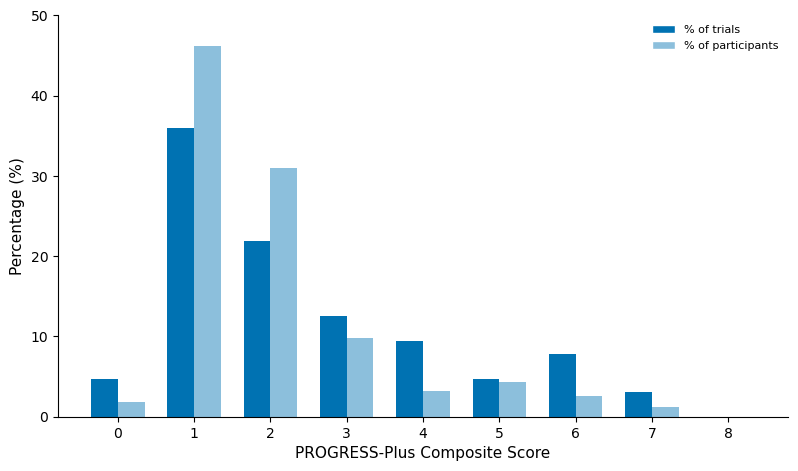

Mean: 2.47
SD: 1.83
Median: 2
IQR: 1–3
Range: 0–7

Figure 7 counts (trials reporting per domain):
                       domain  reported
                   Sex/gender        61
    Social capital (combined)        23
                    Education        18
      Social capital (living)        17
              Health literacy        13
                    Ethnicity        11
                   Occupation        11
             Digital literacy        10
Social capital (relationship)         8
                       Income         5
           Place of residence         4
→ Thesis Figure 6 (PROGRESS-Plus score distribution)


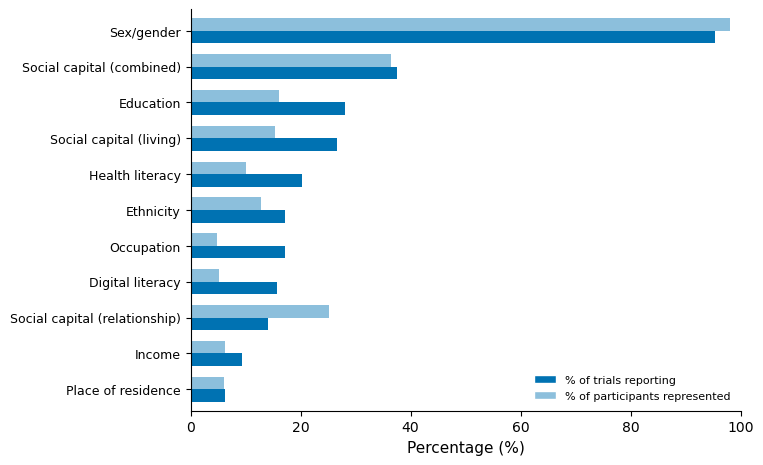

→ Thesis Figure 7 (PROGRESS-Plus reporting completeness)


In [14]:
trials['progress_plus_composite_score'] = compute_progress_plus_composite_scores(arms, trials)
print("PROGRESS-Plus composite score distribution:")
print(trials['progress_plus_composite_score'].value_counts().sort_index().to_string())

fig6 = build_fig_progressplus_score(trials)
save_figure(fig6, "fig6_progressplus_score")
print(f"Mean: {trials['progress_plus_composite_score'].mean():.2f}")
print(f"SD: {trials['progress_plus_composite_score'].std():.2f}")
print(f"Median: {trials['progress_plus_composite_score'].median():.0f}")
print(f"IQR: {trials['progress_plus_composite_score'].quantile(0.25):.0f}\u2013{trials['progress_plus_composite_score'].quantile(0.75):.0f}")
print(f"Range: {trials['progress_plus_composite_score'].min():.0f}\u2013{trials['progress_plus_composite_score'].max():.0f}")

print("\nFigure 7 counts (trials reporting per domain):")
print(reporting_df[['domain', 'reported']].sort_values('reported', ascending=False).to_string(index=False))

print("→ Thesis Figure 6 (PROGRESS-Plus score distribution)")

fig7 = build_fig_progressplus_reporting(trials, arms)
save_figure(fig7, "fig7_progressplus_reporting")
print("→ Thesis Figure 7 (PROGRESS-Plus reporting completeness)")

## Section 6: Digital strategy aggregation

**Boolean aggregation from arm-level to trial-level:** A strategy is marked
present for the trial if **any** intervention arm has it True.

In [15]:
# Digital strategy: aggregate 4 binary arm-level flags → trial-level.
# method='any_true': trial 'has' strategy if any arm has it True.
digital_strategy_fields = [
    'digital_strategy_excludes', 'digital_strategy_provides_equipment',
    'digital_strategy_provides_training', 'digital_strategy_provides_ongoing_support',
]
digital_strategy_labels = ['Excludes', 'Provides equipment', 'Provides training', 'Provides ongoing support']

digital_strategy_flags = trials[['cov_nr', 'healthcare_setting']].copy()
for field in digital_strategy_fields:
    flags = aggregate_boolean_at_trial(int_arms, field, method="any_true")
    digital_strategy_flags[field] = digital_strategy_flags['cov_nr'].map(flags)

# Overall proportions
digital_strategy_rows = []
for field, label in zip(digital_strategy_fields, digital_strategy_labels):
    n_true = digital_strategy_flags[field].sum()
    n_false = (digital_strategy_flags[field] == 0).sum()
    prop = n_true / (n_true + n_false)
    digital_strategy_rows.append({
        'strategy': label, 'field': field,
        'n_yes': n_true, 'n_no': n_false,
        'proportion': prop,
    })

digital_strategy_summary = pd.DataFrame(digital_strategy_rows)
print(digital_strategy_summary.to_string(index=False))
trials = trials.merge(digital_strategy_flags[['cov_nr'] + digital_strategy_fields], on='cov_nr', how='left')

digital_strategy_summary.to_csv(OUTPUT_TABLES / 'table5_digital_strategy.csv', index=False)
print("\nSaved: table5_digital_strategy.csv")


                strategy                                     field  n_yes  n_no  proportion
                Excludes                 digital_strategy_excludes     37    27    0.578125
      Provides equipment       digital_strategy_provides_equipment     33    31    0.515625
       Provides training        digital_strategy_provides_training     40    24    0.625000
Provides ongoing support digital_strategy_provides_ongoing_support     26    38    0.406250

Saved: table5_digital_strategy.csv


## Section 7: Digital inclusiveness score

**Digital inclusiveness score (range 0–5):**

| excludes | equipment | training | support | Score | Interpretation |
|---|---|---|---|---|---|
| 1 | 0 | 0 | 0 | **0** | Fully excluded — no digital access |
| 0 | 1 | 0 | 0 | **1** | Equipment provided, no training/support |
| 0 | 1 | 1 | 0 | **3** | Equipment + training — usable pathway |
| 0 | 1 | 1 | 1 | **5** | Full support: equipment + training + ongoing |
| 0 | 0 | 0 | 0 | **2** | No exclusion, no digital strategy |

Formula: `not_excl = ~excludes;  not_equip = ~equipment;  not_train = ~training`
`score = not_excl * (2*not_equip + equipment * (1 + 2*training + 2*training*support))`


Digital inclusiveness score distribution:
digital_inclusiveness_score
0    21
1     3
2    13
3    12
4     8
5     7

Mean: 2.06
SD: 1.75
Median: 2
IQR: 0–3
Range: 0–5

Table AX. Digital inclusiveness score for all 16 combinations (N=64 trials)
 exclusion  equipment  training  support  n_trials  score
         1          0         1        0        10      0
         1          0         0        0         5      0
         1          0         1        1         5      0
         1          0         0        1         1      0
         1          1         0        0         3      1
         0          0         0        0         8      2
         1          1         1        0         3      2
         1          1         0        1         2      2
         1          1         1        1         8      3
         0          1         0        0         3      3
         0          0         1        0         1      3
         0          0         0        1         0      3


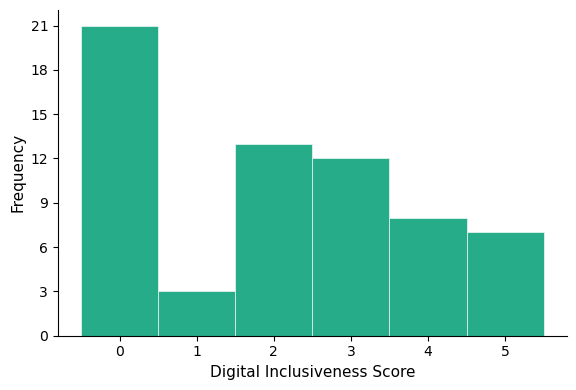

→ Thesis Figure 8 (digital inclusiveness score distribution)


In [16]:
# Digital inclusiveness score (0–5)
# Score = 2*(1−exclusion) + equipment + (training × pathway) + (support × pathway)
# pathway = (1−exclusion) OR equipment

excl = trials.set_index('cov_nr')['digital_strategy_excludes']
equip = trials.set_index('cov_nr')['digital_strategy_provides_equipment']
train = trials.set_index('cov_nr')['digital_strategy_provides_training']
support = trials.set_index('cov_nr')['digital_strategy_provides_ongoing_support']

ne = (~excl.astype(bool)).astype(int)
e = equip.astype(int)
fp = ((~excl.astype(bool)) | equip.astype(bool)).astype(int)

score = 2*ne + e + (train.astype(bool) & fp.astype(bool)).astype(int) + (support.astype(bool) & fp.astype(bool)).astype(int)

trials['digital_inclusiveness_score'] = trials['cov_nr'].map(score)
print("Digital inclusiveness score distribution:")
print(trials['digital_inclusiveness_score'].value_counts().sort_index().to_string())
print(f"\nMean: {trials['digital_inclusiveness_score'].mean():.2f}")
print(f"SD: {trials['digital_inclusiveness_score'].std():.2f}")
print(f"Median: {trials['digital_inclusiveness_score'].median():.0f}")
print(f"IQR: {trials['digital_inclusiveness_score'].quantile(0.25):.0f}\u2013{trials['digital_inclusiveness_score'].quantile(0.75):.0f}")
print(f"Range: {trials['digital_inclusiveness_score'].min():.0f}\u2013{trials['digital_inclusiveness_score'].max():.0f}")

# ── 16-way combination table ─────────────────────────────────────────────────
# All 2^4 permutations of the 4 binary digital-strategy indicators, with trial
# counts and the computed digital inclusiveness score for each row.
combos = []
for e_excl in [0, 1]:
    for e_equip in [0, 1]:
        for e_train in [0, 1]:
            for e_support in [0, 1]:
                mask = (
                    (trials['digital_strategy_excludes'] == e_excl) &
                    (trials['digital_strategy_provides_equipment'] == e_equip) &
                    (trials['digital_strategy_provides_training'] == e_train) &
                    (trials['digital_strategy_provides_ongoing_support'] == e_support)
                )
                n_trials = mask.sum()
                pathway = int(not bool(e_excl) or bool(e_equip))
                combo_score = 2 * (1 - e_excl) + e_equip + (e_train * pathway) + (e_support * pathway)
                combos.append({
                    'exclusion': e_excl,
                    'equipment': e_equip,
                    'training': e_train,
                    'support': e_support,
                    'n_trials': n_trials,
                    'score': combo_score,
                })

combo_df = pd.DataFrame(combos)
combo_df = combo_df.sort_values(['score', 'n_trials'], ascending=[True, False]).reset_index(drop=True)
print("\nTable AX. Digital inclusiveness score for all 16 combinations (N=64 trials)")
print(combo_df.to_string(index=False))

# Save CSV
combo_df.to_csv(OUTPUT_TABLES / 'table_ax_digital_combinations.csv', index=False)

# Save .tex (booktabs fragment for LaTeX \input)
THESIS_TABLES = ROOT / "thesis_latex" / "tables"
tex_lines = [
    "\\begin{table}[htbp]",
    "  \\centering",
    "  \\caption{Digital inclusiveness score for all 16 combinations of the four binary digital-strategy indicators (N=64 trials)}",
    "  \\label{tab:ax_digital_combinations}",
    "  \\begin{tabular}{c c c c c c}",
    "    \\toprule",
    "    Exclusion & Equipment & Training & Support & Trials (n) & Score \\\\",
    "    \\midrule",
]
for _, row in combo_df.iterrows():
    tex_lines.append(
        f"    {row['exclusion']} & {row['equipment']} & {row['training']} & {row['support']} & {row['n_trials']} & {row['score']} \\\\"
    )
tex_lines.extend([
    "    \\bottomrule",
    "  \\end{tabular}",
    "  \\par",
    "  {\\footnotesize Functional pathway present when exclusion = 0 OR equipment = 1. Score = 2$\\times$(1 $-$ exclusion) + equipment + (training $\\times$ pathway) + (support $\\times$ pathway); range 0--5.}",
    "\\end{table}",
])
tex_path = THESIS_TABLES / "table_ax_digital_combinations.tex"
tex_path.write_text("\n".join(tex_lines) + "\n")
print(f"Saved: {tex_path}")

# ── Simple trial-level distribution histogram ────────────────────────────────
fig8 = histogram_with_stats(
    trials['digital_inclusiveness_score'].dropna().values,
    xlabel="Digital Inclusiveness Score",
    bins=np.arange(-0.5, 6.5, 1), color=GREEN, integer_x=True,
    show_median_iqr=False, show_stats_box=False,
)
fig8.axes[0].yaxis.set_major_locator(MaxNLocator(integer=True))
save_figure(fig8, "fig8_digital_inclusiveness")
print("\u2192 Thesis Figure 8 (digital inclusiveness score distribution)")


## Section 8: Hypothesis 1 — Equity reporting over time

**Ordinary Least Squares (OLS)** is the method by which linear regression fits
a line through data. The “best” line minimises the sum of squared vertical
distances between each observed point and the line.

> **Why squared?** Squaring penalises large deviations disproportionately
> (a residual of 4 → 16; two residuals of 2 → 8 total). This makes OLS
> responsive to outliers — for better or worse. It also makes the math
> tractable (closed-form solution).

The output: an **intercept** (where the line crosses x=0) and a **slope** (β —
how much Y changes per unit increase in X), each with standard errors, CIs, and
p-values via the t-distribution.

**Key assumption:** the relationship between X and Y is linear. OLS will fit
a straight line to anything, even a curve. The diagnostic plots below tell you
whether linearity holds.

**LOWESS (Locally Weighted Scatterplot Smoothing)** is a non-parametric curve
fitted without assuming a specific functional form. It divides the X range into
small windows, fits a local regression in each, and connects them into a smooth
curve.

**Its purpose here:** a *reality check* on the OLS line. If the LOWESS curve
tracks the straight line closely, linearity is defensible. If it curves away,
the linear model is missing structure and the results should be interpreted
cautiously.

### Regression diagnostics

Three diagnostic panels accompany each regression:

**Residuals vs Fitted** — X-axis: predicted values. Y-axis: difference between
observed and predicted. What you want: random scatter around y=0 with no pattern.
A U-shape → non-linear relationship. A fan shape → non-constant variance
(heteroscedasticity), which can bias standard errors.

**QQ plot (Quantile-Quantile)** — X-axis: theoretical normal quantiles. Y-axis:
observed residual quantiles. Points on the 45° line = normal residuals, which
OLS assumes for exact p-values and CIs. Mild deviations are fine (central limit
theorem helps at n~60). Strong deviations — S-shape, heavy tails — mean p-values
may be miscalibrated.

**Cook's Distance** — how much each observation influences the regression fit.
Computed by refitting without observation i and measuring how much the predicted
values change. A common flag: Cook's distance > 4/n (≈ 0.06 at n=65). High
values are worth examining — they may be data errors, legitimate edge cases, or
observations that drive the result. The H1 sensitivity analysis below flags six
such observations and refits without them.


Trials for H1: 64


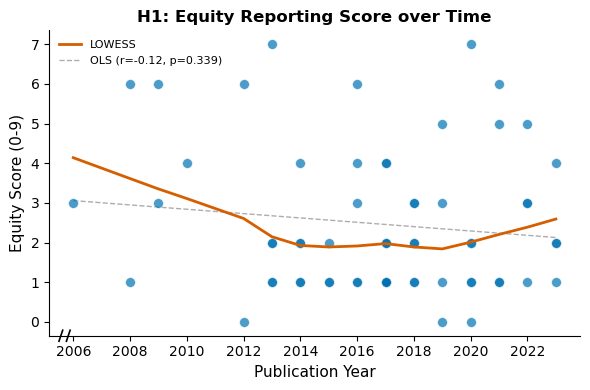

→ Supplementary (H1: equity over time)
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          112.8819    114.667      0.984      0.329    -116.334     342.098
publication_year    -0.0547      0.057     -0.963      0.339      -0.168       0.059

H1: progress_plus_composite_score ~ publication_year
  beta = -0.055 [-0.168, 0.059], p = 0.3393, n = 64


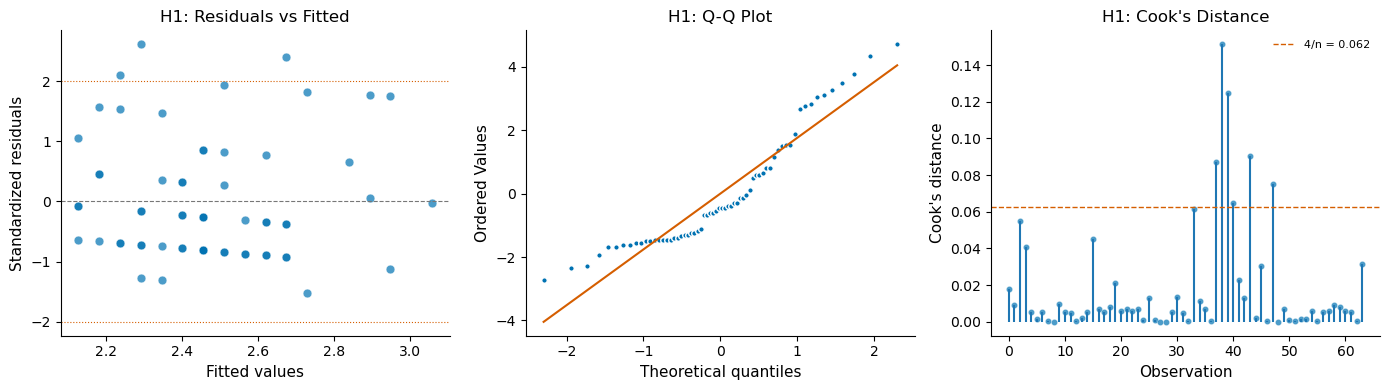

→ Supplementary (H1 diagnostics)


In [17]:
# H1: Has equity reporting improved over 2006–2023?
# OLS: progress_plus_composite_score ~ publication_year. LOWESS as linearity check.
# Three diagnostic panels: residuals, Q-Q, Cook's distance.
valid_h1 = trials[['progress_plus_composite_score', 'publication_year']].dropna()
n_h1 = len(valid_h1)
print(f"Trials for H1: {n_h1}")

fig = scatter_with_regression(
    valid_h1['publication_year'].values, valid_h1['progress_plus_composite_score'].values,
    xlabel='Publication Year', ylabel='Equity Score (0-9)',
    title='H1: Equity Reporting Score over Time', color=BLUE, integer_x=True,
)
save_figure(fig, "fig7a_h1_equity_over_time")
print("→ Supplementary (H1: equity over time)")

# Linear regression
model_h1 = smf.ols('progress_plus_composite_score ~ publication_year', data=valid_h1).fit()
print(model_h1.summary().tables[1])

beta = model_h1.params['publication_year']
ci = model_h1.conf_int().loc['publication_year']
p_val = model_h1.pvalues['publication_year']
print(f"\nH1: progress_plus_composite_score ~ publication_year")
print(f"  beta = {beta:.3f} [{ci[0]:.3f}, {ci[1]:.3f}], p = {p_val:.4f}, n = {n_h1}")

fig_diag = regression_diagnostics_plot(model_h1, title_prefix="H1: ")
save_figure(fig_diag, "fig7b_h1_diagnostics")
print("→ Supplementary (H1 diagnostics)")


## Section 9: Hypothesis 2 — Representativeness over time

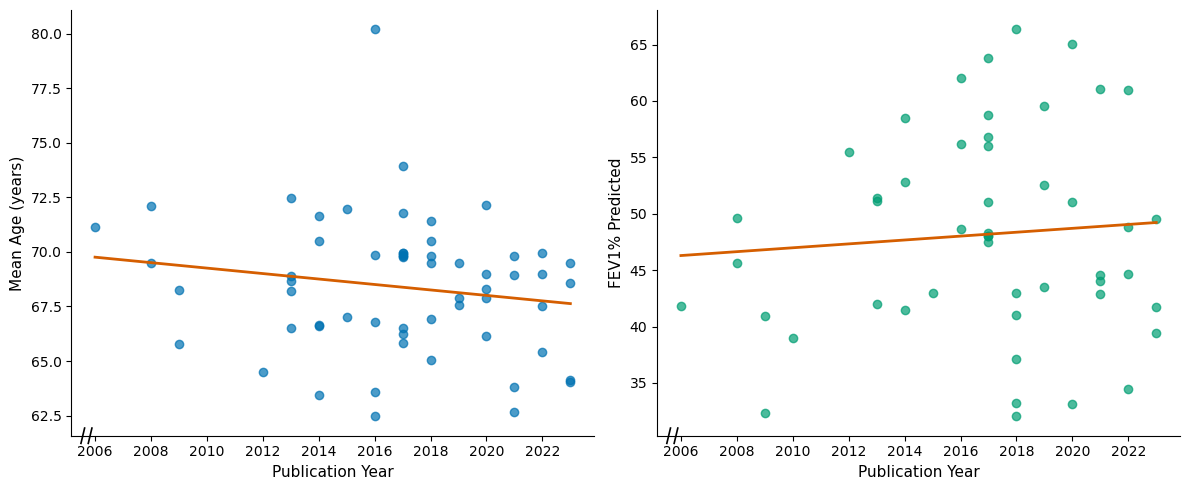

→ Supplementary (H2: representativeness over time)
H2a: Mean age vs year
  beta = -0.125 [-0.326, 0.076], p = 0.2168, n = 59
H2b: FEV1% predicted vs year
  beta = 0.172 [-0.444, 0.788], p = 0.5762, n = 49


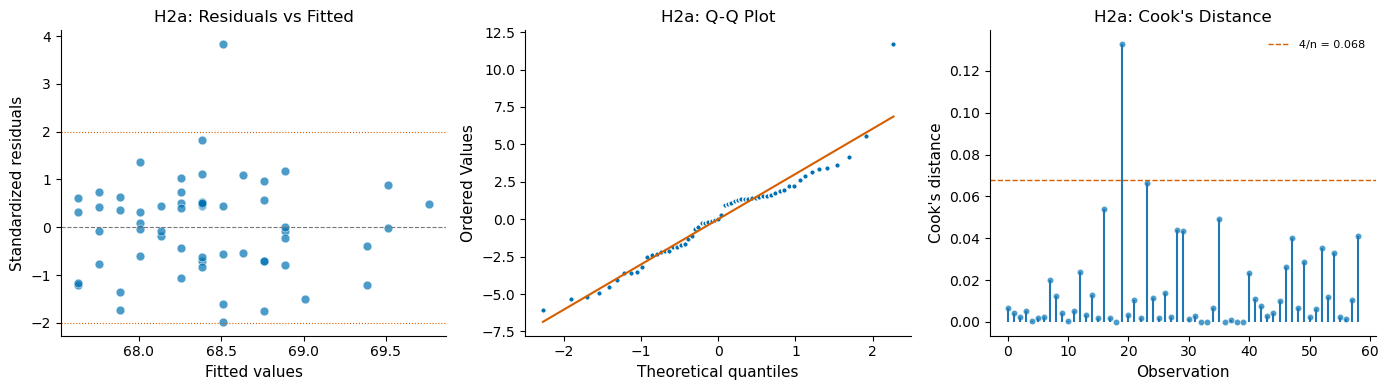

→ Supplementary (H2a: age diagnostics)


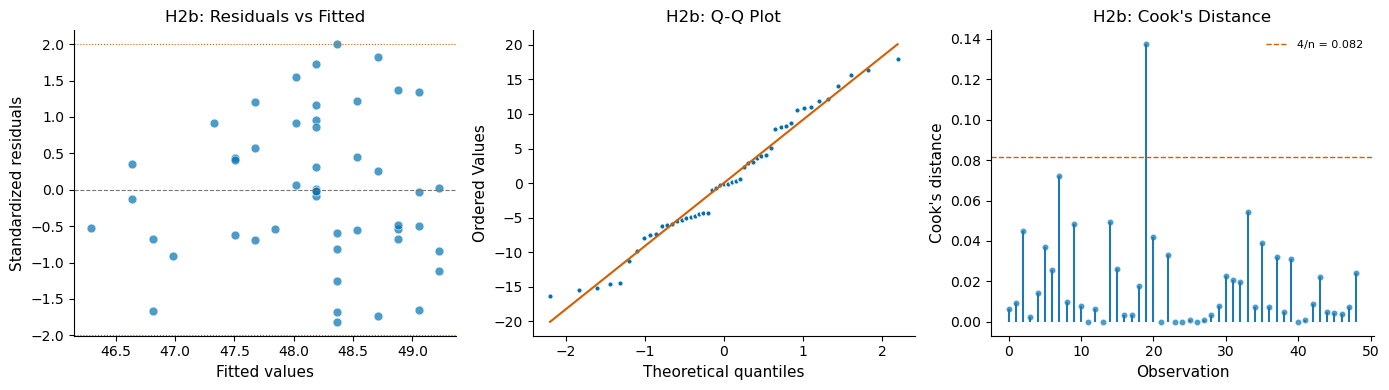

→ Supplementary (H2b: FEV1 diagnostics)


In [18]:
# H2: Have enrolled populations changed over time?
# H2a: age_mean ~ year. H2b: fev1_pct_mean ~ year.

# Fit models
valid_age = trials[['age_mean', 'publication_year']].dropna()
model_h2_age = smf.ols('age_mean ~ publication_year', data=valid_age).fit()
beta_age = model_h2_age.params['publication_year']
ci_age = model_h2_age.conf_int().loc['publication_year']
p_age = model_h2_age.pvalues['publication_year']

valid_fev1 = trials[['fev1_pct_mean', 'publication_year']].dropna()
model_h2_fev1 = smf.ols('fev1_pct_mean ~ publication_year', data=valid_fev1).fit()
beta_fev1 = model_h2_fev1.params['publication_year']
ci_fev1 = model_h2_fev1.conf_int().loc['publication_year']
p_fev1 = model_h2_fev1.pvalues['publication_year']

# === Primary plots ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(valid_age['publication_year'], valid_age['age_mean'], color=BLUE, alpha=0.7)
axis_break_x(ax1)
xr = np.linspace(valid_age['publication_year'].min(), valid_age['publication_year'].max(), 50)
ax1.plot(xr, model_h2_age.params['Intercept'] + model_h2_age.params['publication_year'] * xr, color=RED, linewidth=2)
ax1.set_xlabel('Publication Year'); ax1.set_ylabel('Mean Age (years)')
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

ax2.scatter(valid_fev1['publication_year'], valid_fev1['fev1_pct_mean'], color=GREEN, alpha=0.7)
axis_break_x(ax2)
xr2 = np.linspace(valid_fev1['publication_year'].min(), valid_fev1['publication_year'].max(), 50)
ax2.plot(xr2, model_h2_fev1.params['Intercept'] + model_h2_fev1.params['publication_year'] * xr2, color=RED, linewidth=2)
ax2.set_xlabel('Publication Year'); ax2.set_ylabel('FEV1% Predicted')
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
fig.tight_layout()
save_figure(fig, "fig8a_h2_age_and_fev1_over_time")
print("→ Supplementary (H2: representativeness over time)")

# === Model stats ===
print(f"H2a: Mean age vs year")
print(f"  beta = {beta_age:.3f} [{ci_age[0]:.3f}, {ci_age[1]:.3f}], p = {p_age:.4f}, n = {len(valid_age)}")
print(f"H2b: FEV1% predicted vs year")
print(f"  beta = {beta_fev1:.3f} [{ci_fev1[0]:.3f}, {ci_fev1[1]:.3f}], p = {p_fev1:.4f}, n = {len(valid_fev1)}")

# === Diagnostics ===
fig_d2 = regression_diagnostics_plot(model_h2_age, title_prefix="H2a: ")
save_figure(fig_d2, "fig8b_h2_age_diagnostics")
print("→ Supplementary (H2a: age diagnostics)")
fig_d2b = regression_diagnostics_plot(model_h2_fev1, title_prefix="H2b: ")
save_figure(fig_d2b, "fig8c_h2_fev1_diagnostics")
print("→ Supplementary (H2b: FEV1 diagnostics)")


## Section 10: Hypothesis 3 — Equity vs digital inclusiveness

**Collinearity check & Pearson r**

Before running the regression, we check whether the modified PROGRESS-Plus composite score (0–9) and
digital inclusiveness score (0–5) are collinear. These scores capture different
constructs (demographic reporting vs. digital strategy design), but trials with
equity-awareness may also be more digitally inclusive — so a check is warranted.

**Collinearity** occurs when two predictors are highly correlated. When they
are, the regression cannot separate their individual effects: standard errors
inflate, coefficients become unstable, and conclusions about which predictor
is driving the outcome are unreliable.

**Variance Inflation Factor (VIF)** quantifies how much each predictor's
variance is inflated due to correlation with other predictors. VIF = 1 means no
inflation (orthogonal predictors). Thresholds: VIF > 5 or > 10 are commonly
flagged as problematic.

The diagnostic flow:
1. **Pearson r** between equity score and publication year (bivariate check)
2. **VIF** from a model containing both predictors
3. If |r| ≥ 0.7 or VIF > 5, the model is refit with a single predictor

> H2 has only one predictor (publication_year). Collinearity requires ≥ 2
> variables, so H2 does not need this check. H3 has two predictors — hence the
> diagnostics here.

> **Diagnostic note (residuals vs fitted):** The residuals-vs-fitted plot for H3
> shows a mild pattern deviating from random scatter around zero, suggesting some
> heteroscedasticity. OLS p-values may be slightly anti-conservative as a result;
> coefficients should be interpreted with caution. This is noted in the
> limitations section of the thesis.


Pearson r(progress_plus_composite_score, year) = -0.121 (p=0.339)
VIF:
2.856091
2.856091


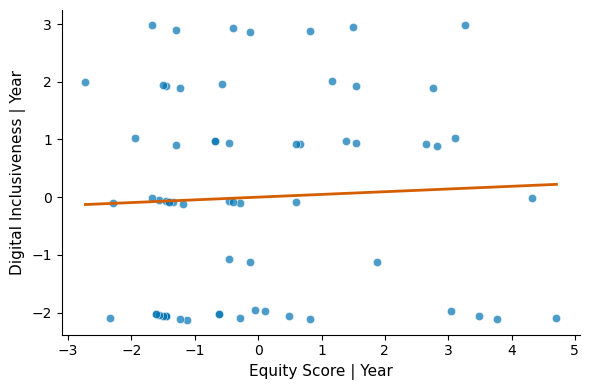

→ Supplementary (H3: equity vs digital)

H3 primary model:
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                       -24.7423    112.588     -0.220      0.827    -249.876     200.391
progress_plus_composite_score     0.0470      0.124      0.380      0.705      -0.200       0.294
publication_year                  0.0132      0.056      0.237      0.813      -0.098       0.125

H3: digital_inclusiveness ~ progress_plus_composite_score + year
  beta_equity = 0.047 [-0.200, 0.294], p = 0.7052, n = 64


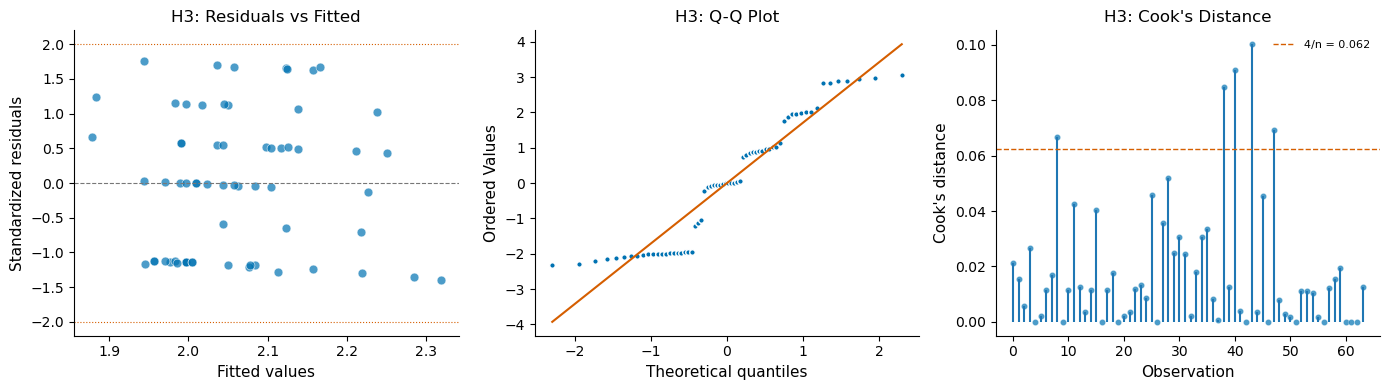

→ Supplementary (H3 diagnostics)


In [19]:
# H3: Are equity-conscious trials more digitally inclusive?
# Collinearity check first (VIF > 5 = problematic, |r| > 0.7).
# OLS: digital_inclusiveness ~ progress_plus_composite_score + year.
valid_h3 = trials[['progress_plus_composite_score', 'digital_inclusiveness_score', 'publication_year']].dropna()
n_h3 = len(valid_h3)

# Collinearity check
r, pearson_p = pearson_correlation(valid_h3['progress_plus_composite_score'].tolist(), valid_h3['publication_year'].tolist())
print(f"Pearson r(progress_plus_composite_score, year) = {r:.3f} (p={pearson_p:.3f})")

vif = vif_from_model(valid_h3[['progress_plus_composite_score', 'publication_year']])
print("VIF:")
print(vif.to_string(index=False))

if abs(r) >= 0.7:
    print("⚠️ Collinearity |r| >= 0.7: will also fit unadjusted model")

# Fit models
model_h3 = smf.ols('digital_inclusiveness_score ~ progress_plus_composite_score + publication_year', data=valid_h3).fit()
beta_h3 = model_h3.params['progress_plus_composite_score']
ci_h3 = model_h3.conf_int().loc['progress_plus_composite_score']
p_h3 = model_h3.pvalues['progress_plus_composite_score']

# === Primary plot ===
resid_y = smf.ols('digital_inclusiveness_score ~ publication_year', data=valid_h3).fit().resid
resid_x = smf.ols('progress_plus_composite_score ~ publication_year', data=valid_h3).fit().resid

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(resid_x, resid_y, color=BLUE, alpha=0.7, edgecolors='white', linewidth=0.5)
axis_break_x(ax)
beta_partial = np.polyfit(resid_x, resid_y, 1)[0]
xr = np.linspace(resid_x.min(), resid_x.max(), 50)
ax.plot(xr, beta_partial * xr, color=RED, linewidth=2)
ax.set_xlabel('Equity Score | Year')
ax.set_ylabel('Digital Inclusiveness | Year')
fig.tight_layout()
save_figure(fig, "fig9a_h3_equity_vs_digital")
print("→ Supplementary (H3: equity vs digital)")

# === Model stats ===
print("\nH3 primary model:")
print(model_h3.summary().tables[1])
print(f"\nH3: digital_inclusiveness ~ progress_plus_composite_score + year")
print(f"  beta_equity = {beta_h3:.3f} [{ci_h3[0]:.3f}, {ci_h3[1]:.3f}], p = {p_h3:.4f}, n = {n_h3}")

# Unadjusted if collinear
if abs(r) >= 0.7:
    model_h3_unadj = smf.ols('digital_inclusiveness_score ~ progress_plus_composite_score', data=valid_h3).fit()
    print("\nH3 unadjusted:")
    print(model_h3_unadj.summary().tables[1])

# === Diagnostics ===
fig_d3 = regression_diagnostics_plot(model_h3, title_prefix="H3: ")
save_figure(fig_d3, "fig9b_h3_diagnostics")
print("→ Supplementary (H3 diagnostics)")


Spearman ρ(digital_inclusiveness, progress_plus_composite) = 0.093, p = 0.4657, n = 64


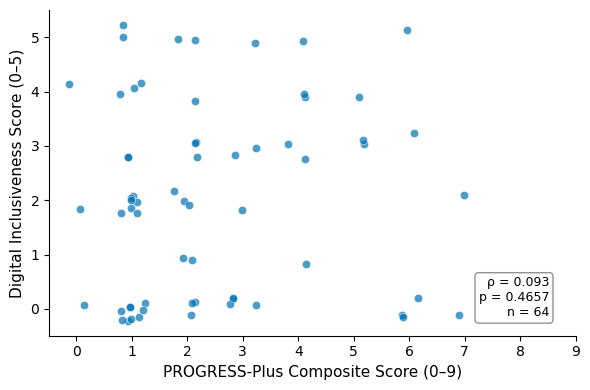

→ Supplementary (H3: Spearman ρ scatterplot)


In [20]:
# ── H3 exploratory: Spearman rank correlation ──────────────────────────
# Spearman ρ is more appropriate than Pearson for two ordinal composite scores.
# Both vars already filtered to non-NA in valid_h3 from the cell above.
rho_h3, p_spear_h3 = spearman_correlation(
    valid_h3['digital_inclusiveness_score'].tolist(),
    valid_h3['progress_plus_composite_score'].tolist()
)
print(f"Spearman ρ(digital_inclusiveness, progress_plus_composite) = {rho_h3:.3f}, p = {p_spear_h3:.4f}, n = {n_h3}")

# ── Scatterplot (fig9c) ────────────────────────────────────────────────
# Raw scores, not partial residuals. Jitter needed — both are integer counts.
rng = np.random.default_rng(42)
n_pts = len(valid_h3)
jitter_x = valid_h3['progress_plus_composite_score'].values + rng.uniform(-0.25, 0.25, size=n_pts)
jitter_y = valid_h3['digital_inclusiveness_score'].values + rng.uniform(-0.25, 0.25, size=n_pts)

fig_spear, ax_spear = plt.subplots(figsize=(6, 4))
ax_spear.scatter(jitter_x, jitter_y, color=BLUE, alpha=0.7, edgecolors='white', linewidth=0.5)
ax_spear.set_xlabel('PROGRESS-Plus Composite Score (0–9)')
ax_spear.set_ylabel('Digital Inclusiveness Score (0–5)')
ax_spear.set_xticks(range(10))
ax_spear.set_yticks(range(6))
ax_spear.text(0.95, 0.05,
    f"ρ = {rho_h3:.3f}\np = {p_spear_h3:.4f}\nn = {n_pts}",
    transform=ax_spear.transAxes, ha='right', va='bottom', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=GRAY, alpha=0.8))
fig_spear.tight_layout()
save_figure(fig_spear, "fig9c_h3_spearman")
print("→ Supplementary (H3: Spearman ρ scatterplot)")


## Section 11: Compile results table

In [21]:
results_rows = [
    {
        'hypothesis': 'H1', 'predictor': 'publication_year',
        'outcome': 'progress_plus_composite_score',
        'beta': model_h1.params['publication_year'],
        'ci_lower': model_h1.conf_int().loc['publication_year', 0],
        'ci_upper': model_h1.conf_int().loc['publication_year', 1],
        'raw_p': model_h1.pvalues['publication_year'], 'n': n_h1,
    },
    {
        'hypothesis': 'H2a_age', 'predictor': 'publication_year',
        'outcome': 'age_mean',
        'beta': beta_age, 'ci_lower': ci_age[0], 'ci_upper': ci_age[1],
        'raw_p': p_age, 'n': len(valid_age),
    },
    {
        'hypothesis': 'H2b_fev1', 'predictor': 'publication_year',
        'outcome': 'fev1_pct_mean',
        'beta': beta_fev1, 'ci_lower': ci_fev1[0], 'ci_upper': ci_fev1[1],
        'raw_p': p_fev1, 'n': len(valid_fev1),
    },
    {
        'hypothesis': 'H3', 'predictor': 'equity_score (adj. year)',
        'outcome': 'digital_inclusiveness_score',
        'beta': beta_h3, 'ci_lower': ci_h3[0], 'ci_upper': ci_h3[1],
        'raw_p': p_h3, 'n': n_h3,
    },
    {
        'hypothesis': 'H3_spearman', 'predictor': 'equity_score',
        'outcome': 'digital_inclusiveness_score',
        'beta': rho_h3, 'ci_lower': None, 'ci_upper': None,
        'raw_p': p_spear_h3, 'n': n_h3,
    },
]

results_df = pd.DataFrame(results_rows)
results_df.to_csv(OUTPUT_TABLES / 'table6a_inferential_results.csv', index=False)
print("Saved: table6_inferential_results.csv")
print(results_df.to_string(index=False))

# Summary
inf_results = {f'{r["hypothesis"]}_{k}': v for r in results_rows
           for k, v in r.items() if k != 'hypothesis'}
pd.DataFrame([inf_results]).to_csv(OUTPUT_TABLES / 'table6b_inferential_summary.csv', index=False)
print("\nSaved: inferential_summary.csv")


Saved: table6_inferential_results.csv
 hypothesis                predictor                       outcome      beta  ci_lower  ci_upper    raw_p  n
         H1         publication_year progress_plus_composite_score -0.054748 -0.168404  0.058908 0.339337 64
    H2a_age         publication_year                      age_mean -0.125172 -0.325867  0.075523 0.216799 59
   H2b_fev1         publication_year                 fev1_pct_mean  0.172326 -0.443540  0.788191 0.576174 49
         H3 equity_score (adj. year)   digital_inclusiveness_score  0.047027 -0.200395  0.294448 0.705218 64
H3_spearman             equity_score   digital_inclusiveness_score  0.092817       NaN       NaN 0.465708 64

Saved: inferential_summary.csv


## Section 12: Sensitivity 1 — Arm-level vs trial-level baseline
**Arm-level vs trial-level:** Arm-level averages weight each arm equally
(simple mean across all 134 arms). Trial-level averages first aggregate
arms within each trial (n-weighted), then average across the 64 trials.
Differences arise when trials with more arms or unbalanced arm sizes
influence one level more than the other. The comparison shows whether
the arm-level picture materially differs from the trial-level picture
— if they agree, the trial-level summary is robust to aggregation choice.


In [22]:
# Arm-level vs trial-level baseline comparison. If arm sizes are balanced,
# these should agree. Large discrepancies suggest influential trials.
baseline_cols = ['age_mean', 'gender_pct_female', 'fev1_pct_mean', 'bmi_mean']
s2_rows = []

for col in baseline_cols:
    # Trial-level (already done in 02)
    p = weighted_mean_across_trials(trials, col, 'total_n')

    # Arm-level: each arm as a row, unweighted
    arm_vals = arms[col].dropna()
    arm_mean = float(arm_vals.mean())
    arm_se = float(stats.sem(arm_vals)) if len(arm_vals) > 1 else None
    t_crit = stats.t.ppf(0.975, df=len(arm_vals) - 1) if len(arm_vals) > 1 else None
    arm_ci_lo = arm_mean - t_crit * arm_se if t_crit else None
    arm_ci_hi = arm_mean + t_crit * arm_se if t_crit else None

    s2_rows.append({
        'variable': col,
        'trial_level_weighted': p['weighted_mean'],
        'trial_ci_lo': p['ci_lower'], 'trial_ci_hi': p['ci_upper'],
        'arm_level_simple': arm_mean,
        'arm_ci_lo': arm_ci_lo, 'arm_ci_hi': arm_ci_hi,
        'difference': abs(p['weighted_mean'] - arm_mean) if p['weighted_mean'] is not None else None,
        'n_trials': p['n_trials'], 'n_arms': len(arm_vals),
    })

sens_arm_vs_trial = pd.DataFrame(s2_rows)
sens_arm_vs_trial.to_csv(OUTPUT_TABLES / 'pipeline' / 'table_S2_arm_vs_trial.csv', index=False)
print("Saved: table_S2_arm_vs_trial.csv")
print(sens_arm_vs_trial.to_string(index=False))


Saved: table_S2_arm_vs_trial.csv
         variable  trial_level_weighted  trial_ci_lo  trial_ci_hi  arm_level_simple  arm_ci_lo  arm_ci_hi  difference  n_trials  n_arms
         age_mean             69.787302    68.351062    71.223542         68.353556  67.769585  68.937528    1.433746        59     124
gender_pct_female             46.036645    41.031540    51.041750         40.510547  37.384896  43.636198    5.526098        61     128
    fev1_pct_mean             47.510789    45.386008    49.635570         48.183206  46.397219  49.969193    0.672417        49     102
         bmi_mean             26.462347    25.593509    27.331185         26.474783  25.917323  27.032242    0.012436        32      69


## Section 13: Sensitivity 2 — Weighted vs unweighted pooling

In [23]:
# Weighted vs unweighted pooling. Weighted: larger trials matter more
# (participant perspective). Unweighted: every trial = 1 vote.
# Difference reflects whether large trials enroll different populations.
s3_rows = []
for col in baseline_cols:
    p_w = weighted_mean_across_trials(trials, col, 'total_n')
    p_u = simple_mean_across_trials(trials, col)
    s3_rows.append({
        'variable': col,
        'weighted_mean': p_w['weighted_mean'],
        'weighted_ci_lo': p_w['ci_lower'], 'weighted_ci_hi': p_w['ci_upper'],
        'unweighted_mean': p_u['mean'],
        'unweighted_ci_lo': p_u['ci_lower'], 'unweighted_ci_hi': p_u['ci_upper'],
        'difference': abs(p_w['weighted_mean'] - p_u['mean'])
        if p_w['weighted_mean'] is not None and p_u['mean'] is not None else None,
        'n_trials': p_w['n_trials'],
    })

sens_weighted = pd.DataFrame(s3_rows)
sens_weighted.to_csv(OUTPUT_TABLES / 'pipeline' / 'table_S3_weighted_vs_unweighted.csv', index=False)
print("Saved: table_S3_weighted_vs_unweighted.csv")
print(sens_weighted.to_string())


# Compact display with abbreviated column names
sens_weighted = sens_weighted.rename(columns={'weighted_mean': 'w_mean', 'weighted_ci_lo': 'w_lo', 'weighted_ci_hi': 'w_hi', 'unweighted_mean': 'uw_mean', 'unweighted_ci_lo': 'uw_lo', 'unweighted_ci_hi': 'uw_hi', 'difference': 'diff', 'n_trials': 'n'})
print(sens_weighted.to_string())

Saved: table_S3_weighted_vs_unweighted.csv
            variable  weighted_mean  weighted_ci_lo  weighted_ci_hi  unweighted_mean  unweighted_ci_lo  unweighted_ci_hi  difference  n_trials
0           age_mean      69.787302       68.351062       71.223542        68.398274         67.591858         69.204691    1.389028        59
1  gender_pct_female      46.036645       41.031540       51.041750        40.421383         36.019899         44.822867    5.615262        61
2      fev1_pct_mean      47.510789       45.386008       49.635570        48.161590         45.567759         50.755421    0.650801        49
3           bmi_mean      26.462347       25.593509       27.331185        26.533292         25.724266         27.342318    0.070945        32
            variable     w_mean       w_lo       w_hi    uw_mean      uw_lo      uw_hi      diff   n
0           age_mean  69.787302  68.351062  71.223542  68.398274  67.591858  69.204691  1.389028  59
1  gender_pct_female  46.036645  41.0315

## Section 14: Sensitivity 3 — Influential observations

In [24]:
# Threshold computed per model: 4 / n_obs
models = {'H1': model_h1, 'H2a': model_h2_age, 'H2b': model_h2_fev1, 'H3': model_h3}
formulas = {'H1': 'progress_plus_composite_score ~ publication_year',
            'H2a': 'age_mean ~ publication_year',
            'H2b': 'fev1_pct_mean ~ publication_year',
            'H3': 'digital_inclusiveness_score ~ progress_plus_composite_score + publication_year'}
data_frames = {'H1': valid_h1, 'H2a': valid_age, 'H2b': valid_fev1, 'H3': valid_h3}

sensitivity_results = []
for name in ['H1', 'H2a', 'H2b', 'H3']:
    model = models[name]
    data = data_frames[name]
    n = int(model.nobs)
    cd = cooks_distance(model)
    influential = cd > (4 / n)
    n_influential = influential.sum()
    influential_labels = data.index[influential]
    data_clean = data.drop(index=influential_labels)
    model_clean = smf.ols(formulas[name], data=data_clean).fit()
    sensitivity_results.append({
        'hypothesis': name, 'n_obs': n, 'n_influential': n_influential,
        'threshold': round(4 / n, 4),
        'beta_original': round(model.params.iloc[1], 3),
        'beta_clean': round(model_clean.params.iloc[1], 3),
        'p_original': round(model.pvalues.iloc[1], 4),
        'p_clean': round(model_clean.pvalues.iloc[1], 4),
        'influential_cov_nrs': sorted([str(int(trials.loc[idx, 'cov_nr']))
                                       for idx in data.index[influential]]),
    })

sens_influential = pd.DataFrame(sensitivity_results)
sens_influential.to_csv(OUTPUT_TABLES / 'pipeline' / 'table_S4_influential_obs_sensitivity.csv', index=False)
print("Influential observations sensitivity:")
print(sens_influential[['hypothesis', 'n_obs', 'n_influential', 'beta_original',
          'beta_clean', 'p_original', 'p_clean']].to_string())

Influential observations sensitivity:
  hypothesis  n_obs  n_influential  beta_original  beta_clean  p_original  p_clean
0         H1     64              6         -0.055       0.016      0.3393   0.7513
1        H2a     59              1         -0.125      -0.114      0.2168   0.1961
2        H2b     49              1          0.172       0.031      0.5762   0.9205
3         H3     64              5          0.047       0.171      0.7052   0.2294


## Section 15: Results-ready statements

In [25]:
print("=== Primary results ===")
h1_beta = model_h1.params['publication_year']
h1_ci = model_h1.conf_int().loc['publication_year']
h1_p = model_h1.pvalues['publication_year']
print(f"\nH1: Each additional year was associated with a {h1_beta:.3f} change in equity score "
      f"(95% CI [{h1_ci[0]:.3f}, {h1_ci[1]:.3f}], p = {h1_p:.4f}, n = {int(model_h1.nobs)}).")
h2a_beta = model_h2_age.params['publication_year']
h2a_ci = model_h2_age.conf_int().loc['publication_year']
h2a_p = model_h2_age.pvalues['publication_year']
print(f"\nH2a: Each additional year was associated with a {h2a_beta:.3f}-year change in mean age "
      f"(95% CI [{h2a_ci[0]:.3f}, {h2a_ci[1]:.3f}], p = {h2a_p:.4f}, n = {int(model_h2_age.nobs)}).")
h2b_beta = model_h2_fev1.params['publication_year']
h2b_ci = model_h2_fev1.conf_int().loc['publication_year']
h2b_p = model_h2_fev1.pvalues['publication_year']
print(f"\nH2b: Each additional year was associated with a {h2b_beta:.3f} percentage-point change in FEV1% predicted "
      f"(95% CI [{h2b_ci[0]:.3f}, {h2b_ci[1]:.3f}], p = {h2b_p:.4f}, n = {int(model_h2_fev1.nobs)}).")
h3_beta = model_h3.params['progress_plus_composite_score']
h3_ci = model_h3.conf_int().loc['progress_plus_composite_score']
h3_p = model_h3.pvalues['progress_plus_composite_score']
print(f"\nH3: Each additional equity domain reported was associated with a {h3_beta:.3f} "
      f"change in digital inclusiveness score "
      f"(95% CI [{h3_ci[0]:.3f}, {h3_ci[1]:.3f}], p = {h3_p:.4f}, n = {int(model_h3.nobs)}), "
      f"adjusted for publication year.")

print(f"\nExploratory (not pre-registered): Spearman ρ between digital inclusiveness "
      f"and PROGRESS-Plus composite score was {rho_h3:.3f} "
      f"(p = {p_spear_h3:.4f}, n = {int(model_h3.nobs)}), "
      f"consistent with the non-significant OLS result in H3.")
print("\n=== Influential obs sensitivity ===")
for _, row in sens_influential.iterrows():
    direction = 'increased' if row['beta_clean'] > row['beta_original'] else 'decreased'
    print(f"\n{row['hypothesis']}: Excluding {int(row['n_influential'])} influential point(s) "
          f"{direction} the beta from {row['beta_original']:.3f} to {row['beta_clean']:.3f} "
          f"(change: {row['beta_clean'] - row['beta_original']:+.3f}).")
    if row['influential_cov_nrs']:
        print(f"  Excluded: {row['influential_cov_nrs']}")

=== Primary results ===

H1: Each additional year was associated with a -0.055 change in equity score (95% CI [-0.168, 0.059], p = 0.3393, n = 64).

H2a: Each additional year was associated with a -0.125-year change in mean age (95% CI [-0.326, 0.076], p = 0.2168, n = 59).

H2b: Each additional year was associated with a 0.172 percentage-point change in FEV1% predicted (95% CI [-0.444, 0.788], p = 0.5762, n = 49).

H3: Each additional equity domain reported was associated with a 0.047 change in digital inclusiveness score (95% CI [-0.200, 0.294], p = 0.7052, n = 64), adjusted for publication year.

Exploratory (not pre-registered): Spearman ρ between digital inclusiveness and PROGRESS-Plus composite score was 0.093 (p = 0.4657, n = 64), consistent with the non-significant OLS result in H3.

=== Influential obs sensitivity ===

H1: Excluding 6 influential point(s) increased the beta from -0.055 to 0.016 (change: +0.071).
  Excluded: ['4104', '4106', '4108', '4123', '4345', '4736']

H2a:

## Section 16: Summary export

In [26]:
trial_setting_counts = trials['healthcare_setting_label'].value_counts()
trial_summary = {
    'n_trials': len(trials),
    'n_arms': len(arms),
    'year_range': f"{years.min():.0f}-{years.max():.0f}",
    'total_participants': int(trials['total_n'].sum()),
    'n_countries': len(country_counts),
    'pct_primary': float(trial_setting_counts.get('Primary', 0) / len(trials) * 100),
    'pct_secondary': float(trial_setting_counts.get('Secondary', 0) / len(trials) * 100),
    'pct_community': float(trial_setting_counts.get('Community', 0) / len(trials) * 100),
}

for var in baseline_cols:
    if var in pooled:
        p = pooled[var]
        trial_summary[f'{var}_pooled'] = p['weighted_mean']
        trial_summary[f'{var}_ci_lo'] = p['ci_lower']
        trial_summary[f'{var}_ci_hi'] = p['ci_upper']

summary_df = pd.DataFrame([trial_summary])
summary_df.to_csv(OUTPUT_TABLES / 'table3c_representativeness_summary.csv', index=False)
print("Saved: representativeness_summary.csv")

print("\n=== Notebook 03 complete ===")
print(f"All outputs in outputs/figures/ and outputs/tables/")
# Schema staleness check: compare computed hash against stored version.
# If column schemas changed since last run, downstream notebooks may
# produce stale results.
current_hash = get_schema_hash()
version_file = ROOT / "data" / "processed" / "schema_version.txt"
if version_file.exists():
    stored_hash = version_file.read_text().strip()
    if current_hash != stored_hash:
        print(f"WARNING: Schema hash changed from {stored_hash} to {current_hash} — downstream data may be stale")
    else:
        print(f"Schema hash verified: {current_hash}")
else:
    print(f"Schema hash: {current_hash} (first run — no prior hash stored)")
version_file.write_text(current_hash)


Saved: representativeness_summary.csv

=== Notebook 03 complete ===
All outputs in outputs/figures/ and outputs/tables/
Schema hash verified: 2b702021


8

## Appendix: Supplementary figures

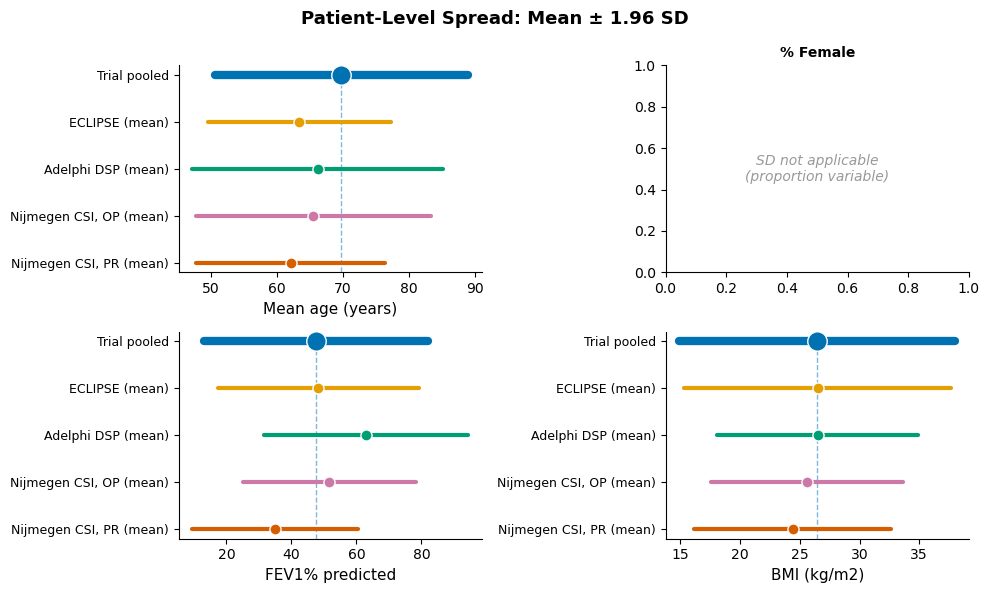

→ Thesis Appendix A (patient-level spread)
Saved: fig3_patient_spread_sd
Whiskers show mean ± 1.96 × SD — the range covering ~95% of individuals per cohort, not precision of the mean estimate.


In [27]:
# Appendix A: Patient-level spread — mean ± 1.96 × SD
# %Female excluded — no within-trial SD for a proportion variable;
# the panel shows "not applicable" annotation by the plotting function.
baseline_var_names = {
    'age_mean': ('Mean age (years)', 'age_years'),
    'gender_pct_female': ('% Female', 'female_pct'),
    'fev1_pct_mean': ('FEV1% predicted', 'fev1_pct_predicted'),
    'bmi_mean': ('BMI (kg/m2)', 'bmi_kg_m2'),
}

fig = forest_plot_means(
    pooled, refs, baseline_var_names, ref_order, ref_labels_short, ref_colors,
    spread="sd", trial_sd_comparison=sd_comparison,
)
save_figure(fig, "fig3b_patient_spread_sd")
print("→ Thesis Appendix A (patient-level spread)")
print("Saved: fig3_patient_spread_sd")
print("Whiskers show mean ± 1.96 × SD — the range covering ~95% of "
      "individuals per cohort, not precision of the mean estimate.")


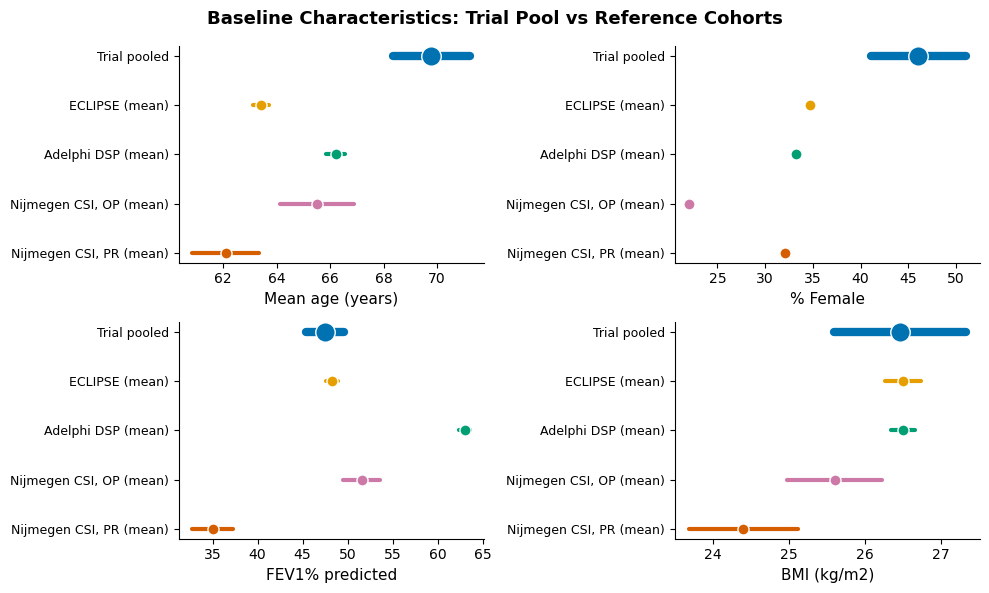

→ Thesis Appendix B (baseline cohort comparison)
Saved: fig3_baseline_cohort_comparison


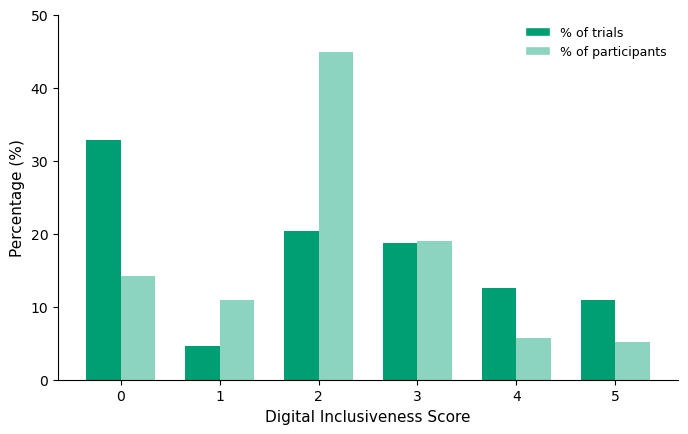

→ Appendix C (participant-weighted digital inclusiveness)


In [28]:
# Appendix B: Baseline cohort comparison (SE-CI)
# --- Forest plot: means with 95% CI ---
fig = forest_plot_means(
    pooled, refs, baseline_var_names, ref_order, ref_labels_short, ref_colors,
    spread="se", show_trial_ref_line=False,
)
save_figure(fig, "fig3e_baseline_cohort_comparison")
print("→ Thesis Appendix B (baseline cohort comparison)")
print("Saved: fig3_baseline_cohort_comparison")

# Appendix C: Participant-weighted digital inclusiveness (dual-panel)
fig6 = build_fig6_combined(trials)
save_figure(fig6, "fig6_combined")
print("→ Appendix C (participant-weighted digital inclusiveness)")
